Проектная работа. Группа 10. Обучение с учителем: Деревья решений. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

# Деревья решений, случайный лес и бустинг

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("X_prepared_sample.csv")

In [3]:
df.head()

,city_development_index,experience,last_new_job,training_hours,target,no_job_info,is_university_enrolled,relevent_experience_No relevent experience,city_city_10,city_city_100,...,education_level_5,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_not_stated,gender_Male,gender_Other,gender_not_stated
0,0.920,21.0,1.0,36.0,1.0,1,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0.776,15.0,5.0,47.0,0.0,0,0,True,False,False,...,False,False,False,False,False,True,False,True,False,False
2,0.624,5.0,0.0,83.0,0.0,1,1,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,0.789,0.0,0.0,52.0,1.0,0,1,True,False,False,...,False,True,False,False,False,False,False,False,False,True
4,0.767,21.0,4.0,8.0,0.0,0,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [4]:
df.target.unique()

array([1., 0.])

2 различных значения в целевой переменной
[1., 0.]

<Axes: xlabel='target', ylabel='count'>

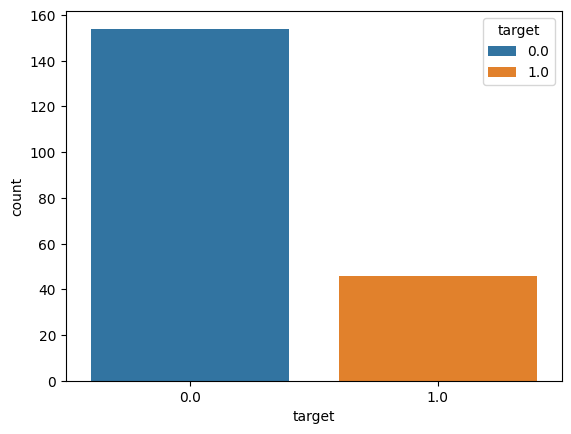

In [5]:
sns.countplot(data=df, x='target', hue='target')

In [6]:
df['target'].value_counts(normalize=True)

,proportion
target,
0.0,0.77
1.0,0.23


Дисбаланс классов примерно 25% (target=1) на 75% (target=0)

**ЗАДАНИЕ: Вычислите корреляцию между различными признаками и колонкой "quality". Чтобы сделать это, Вам можете использовать значения 0 и 1 вместо текстовых значений Legit и Fraud.**

In [7]:
target_corr = df.select_dtypes(include='number').corr()['target']
target_corr

,target
city_development_index,-0.305343
experience,-0.108859
last_new_job,-0.016166
training_hours,0.031419
target,1.000000
no_job_info,0.068596
is_university_enrolled,0.047791


**ЗАДАНИЕ: Нарисуйте график bar plot, отобразив значения корреляции для поддельных вин.**

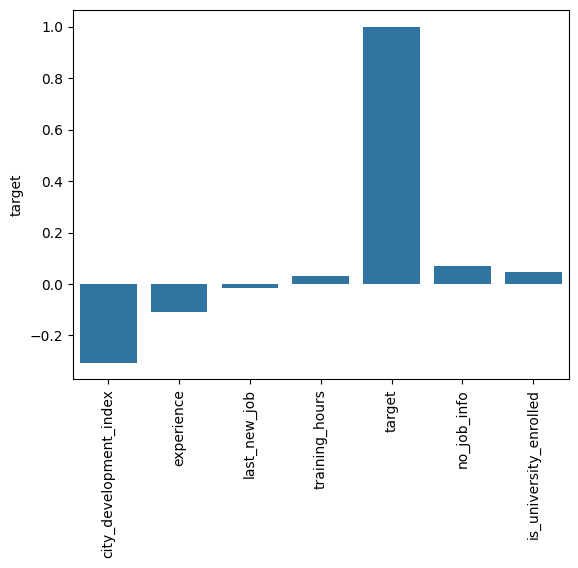

In [8]:
sns.barplot(target_corr)
plt.xticks(rotation=90)
plt.show()

Видим положительную корреляцию target=1 (оттока) c no_job_info (отсутствие прошлой работы).

Отрицательная корреляция особенно сильна с city_development_index

**ЗАДАНИЕ: Нарисуйте график clustermap с помощью seaborn, чтобы исследовать связи между переменными.**

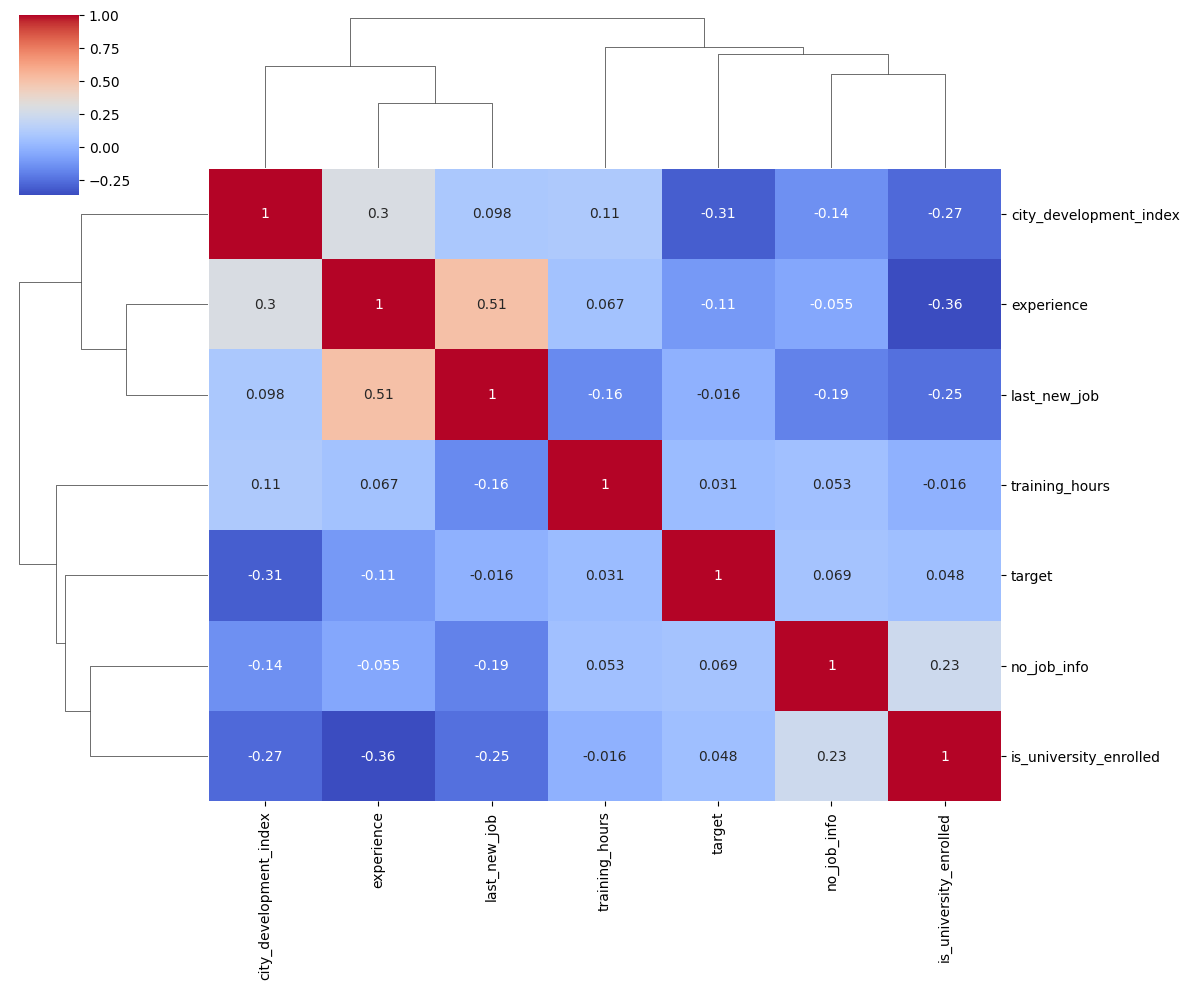

In [9]:
sns.clustermap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', figsize=(12, 10))

----
## Модель машинного обучения

In [3]:
df = pd.read_csv('waterQuality_cleaned.csv')

In [4]:
df.dropna(inplace=True)
X,y = df.drop('target', axis=1), df['target']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve


dummy_model = DummyClassifier(strategy='stratified')

tree_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None],
}
tree_model_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None],
}
rf_model_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

ab_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'algorithm': ['SAMME'],
}
ab_model_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ab_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

gb_param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
}
gb_model_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

In [8]:
named_grids = {
    'DecisionTree':     tree_model_grid,
    'RandomForest':     rf_model_grid,
    'AdaBoost':         ab_model_grid,
    'GradientBoosting': gb_model_grid,
}

dummy_model.fit(X_train, y_train)

for name, grid in named_grids.items():
    print(f"\nRunning GridSearchCV for {name} ...")
    grid.fit(X_train, y_train)
    print(f"  Best params    : {grid.best_params_}")
    print(f"  Best CV ROC-AUC: {grid.best_score_:.4f}")


Running GridSearchCV for DecisionTree ...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


  Best params    : {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
  Best CV ROC-AUC: 0.9578

Running GridSearchCV for RandomForest ...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
  Best params    : {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
  Best CV ROC-AUC: 0.9818

Running GridSearchCV for AdaBoost ...
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/Users/eduard/anaconda3/envs/outfit-transformer/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/eduard/anaconda3/envs/outfit-transformer/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/eduard/anaconda3/envs/outfit-transformer/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/eduard/anaconda3/envs/outfit-transformer/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warning

  Best params    : {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 200}
  Best CV ROC-AUC: 0.9394

Running GridSearchCV for GradientBoosting ...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best params    : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
  Best CV ROC-AUC: 0.9852


In [9]:

results = {}

dummy_roc = roc_auc_score(y_test, dummy_model.predict_proba(X_test)[:, 1])
results['Dummy'] = {'roc_auc': dummy_roc, 'model': dummy_model}
print(f"\nDummy ROC-AUC (test): {dummy_roc:.4f}")

for name, grid in named_grids.items():
    y_scores = grid.predict_proba(X_test)[:, 1]
    roc_auc  = roc_auc_score(y_test, y_scores)
    results[name] = {'roc_auc': roc_auc, 'model': grid.best_estimator_}
    print(f"{name} ROC-AUC (test): {roc_auc:.4f}")

best_name  = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_name]['model']
print(f"\nBest model: {best_name}  (ROC-AUC = {results[best_name]['roc_auc']:.4f})")



Dummy ROC-AUC (test): 0.5063
DecisionTree ROC-AUC (test): 0.9429
RandomForest ROC-AUC (test): 0.9848
AdaBoost ROC-AUC (test): 0.9374
GradientBoosting ROC-AUC (test): 0.9872

Best model: GradientBoosting  (ROC-AUC = 0.9872)


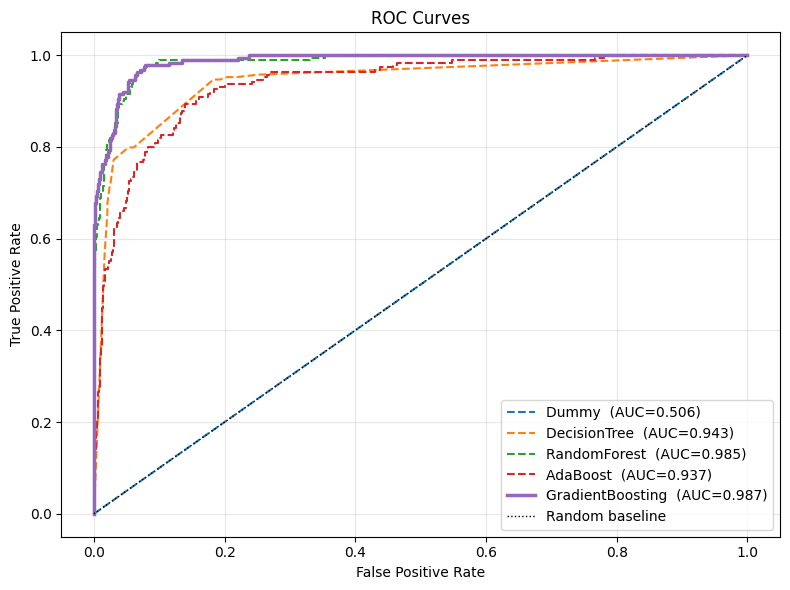

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, info in results.items():
    model    = info['model']
    y_scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    lw = 2.5 if name == best_name else 1.5
    ls = '-'  if name == best_name else '--'
    ax.plot(fpr, tpr, lw=lw, ls=ls, label=f"{name}  (AUC={info['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

/var/folders/t1/m2tfv5zd73qfk8f49z94ln3m0000gn/T/ipykernel_11481/1366579236.py:30: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eduard/anaconda3/envs/outfit-transformer/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


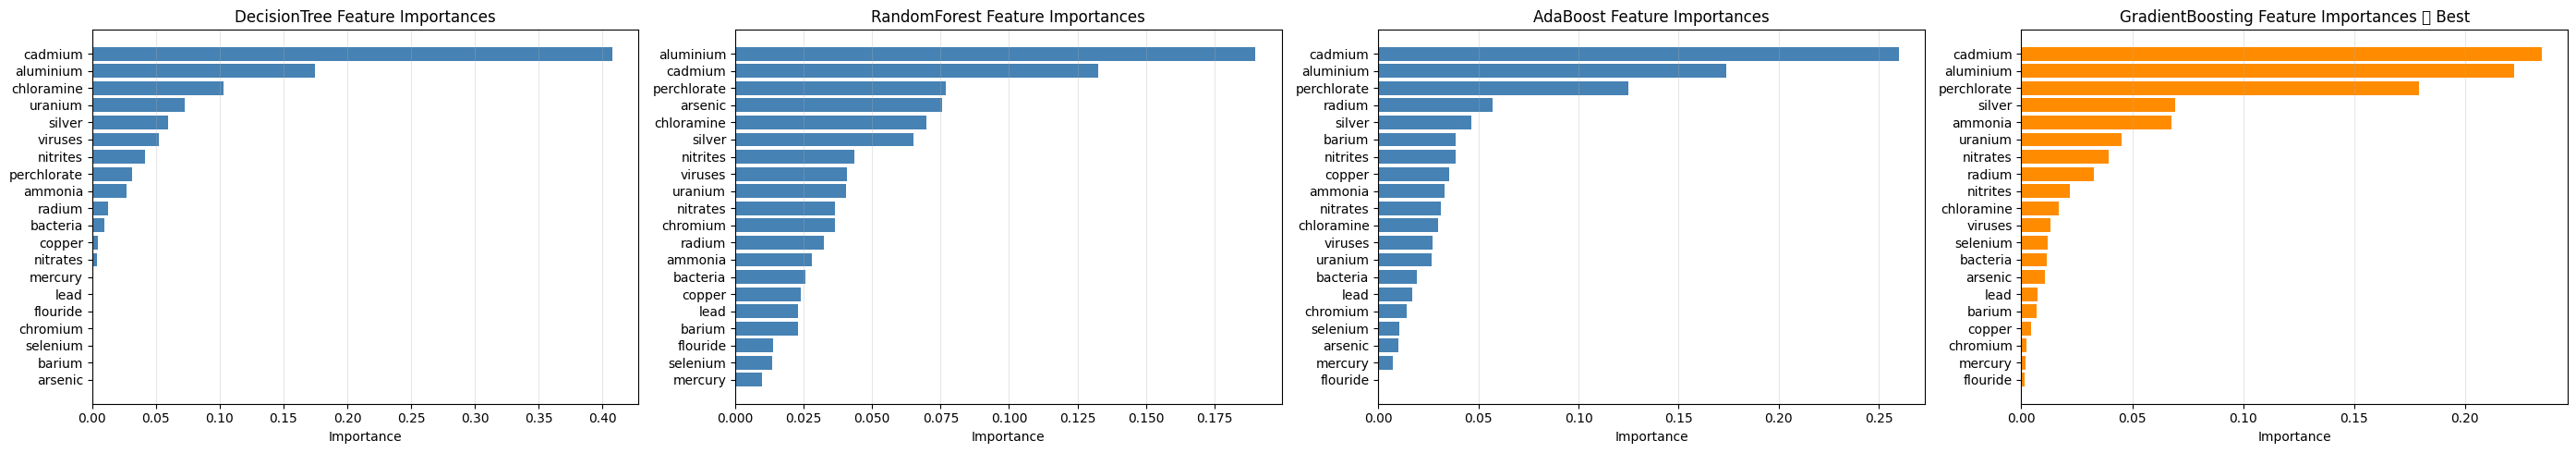

In [13]:
models_with_importances = {
    name: info['model']
    for name, info in results.items()
    if hasattr(info['model'], 'feature_importances_')
}

n_plots = len(models_with_importances)
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

feature_names = X.columns.tolist()

for ax, (name, model) in zip(axes, models_with_importances.items()):
    importances = model.feature_importances_
    idx   = np.argsort(importances)[::-1]
    top_n = min(20, len(feature_names))
    idx   = idx[:top_n]

    ax.barh(
        [feature_names[i] for i in idx[::-1]],
        importances[idx[::-1]],
        color='steelblue' if name != best_name else 'darkorange',
    )
    ax.set_xlabel('Importance')
    ax.set_title(f'{name} Feature Importances'
                 + (' ⭐ Best' if name == best_name else ''))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

ЛУЧШАЯ МОДЕЛЬ — **GradientBoosting**
GradientBoosting показал наивысший ROC-AUC среди всех моделей.


Все 4 модели выделяют одни и те же топ-признаки:

- city_development_index — самый важный признак. Чем выше индекс развития
  города, тем выше вероятность смены работы. Кандидаты из крупных городов
  активнее ищут новые возможности.

- no_job_info — отсутствие информации о текущем работодателе является
  сильным сигналом нестабильности.

- training_hours — больше часов обучения означает выше мотивацию к смене
  работы.

- experience_years — опыт влияет на мобильность кандидата.

- major_discipline_not_stated — неуказанная специализация коррелирует
  с поведением при поиске работы.

- last_new_job — время с момента последней смены работы является
  индикатором "усталости" от текущего места.


DecisionTree — очень высокая концентрация важности на city_development_index
(~0.55). Модель слишком упрощает и фактически опирается почти на один признак,
что может быть признаком переобучения или недостаточной глубины дерева.

RandomForest — более равномерное распределение важности, топ-признаки те же,
но веса сглажены за счёт ансамблирования. Хорошая интерпретируемость.

AdaBoost — похожая картина на RandomForest, но city_development_index снова
доминирует (~0.35). Модель чувствительна к этому признаку.

GradientBoosting (лучшая) — наиболее сбалансированное распределение
важностей. Признаки распределены плавно, что говорит о том, что модель
уловила более сложные взаимозависимости, а не зациклилась на одном сигнале.

Выводы


1. Географический фактор решает. city_development_index — главный драйвер.
   Кандидаты из развитых городов значительно чаще меняют работу, вероятно
   из-за большего числа предложений на рынке.

2. Инвестиции в обучение — двусторонний сигнал. Высокие training_hours могут
   означать, что компания готовит кандидата, который затем уйдёт к конкурентам.

3. Непрозрачность = риск. Отсутствие данных о работодателе (no_job_info)
   и специализации — тревожные сигналы нестабильности кандидата.

4. Тип компании важен. company_type_Funded Startup и company_type_Public Sector
   встречаются в топе у нескольких моделей — сотрудники стартапов и госсектора
   ведут себя по-разному на рынке труда.

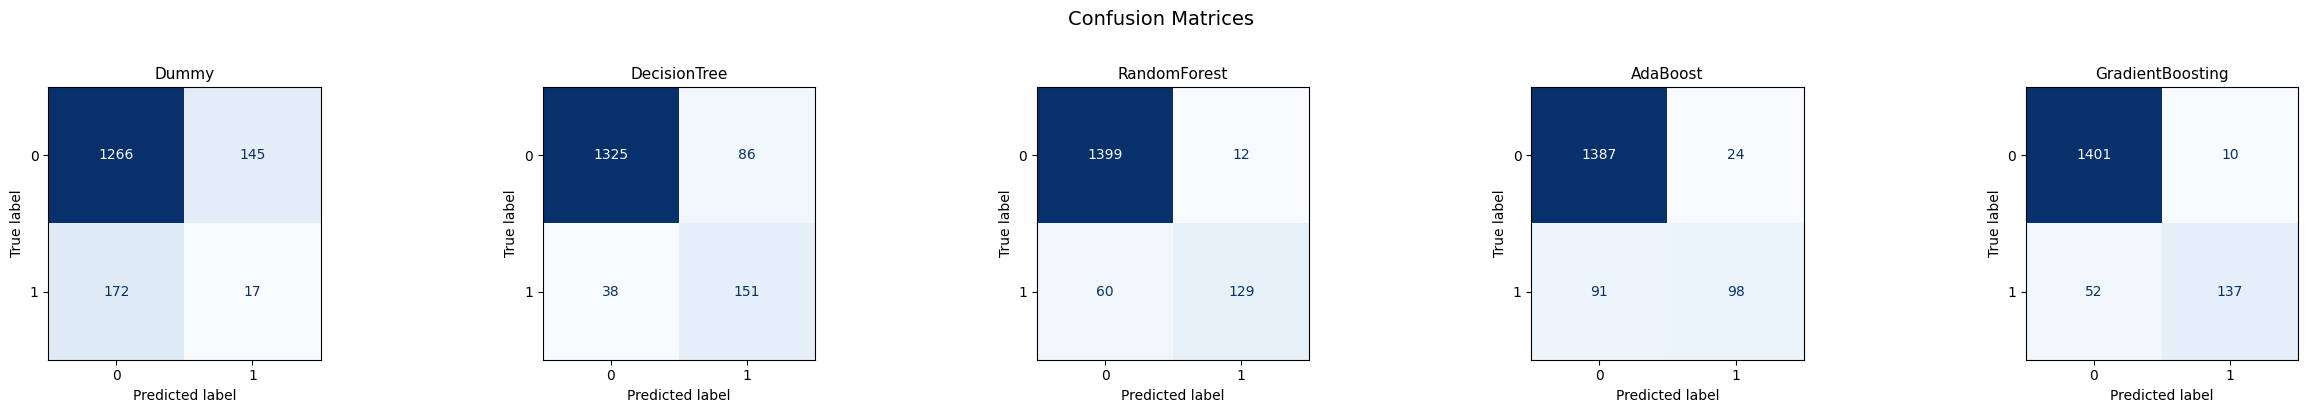


  Dummy
                precision    recall  f1-score   support

not safe water       0.88      0.90      0.89      1411
    safe water       0.13      0.12      0.12       189

      accuracy                           0.80      1600
     macro avg       0.51      0.51      0.51      1600
  weighted avg       0.79      0.80      0.80      1600


  DecisionTree
                precision    recall  f1-score   support

not safe water       0.97      0.94      0.96      1411
    safe water       0.64      0.80      0.71       189

      accuracy                           0.92      1600
     macro avg       0.80      0.87      0.83      1600
  weighted avg       0.93      0.92      0.93      1600


  RandomForest
                precision    recall  f1-score   support

not safe water       0.96      0.99      0.97      1411
    safe water       0.91      0.68      0.78       189

      accuracy                           0.95      1600
     macro avg       0.94      0.84      0.88      1600

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(named_grids) + 1, figsize=(5 * (len(named_grids) + 1), 4))

all_models = {'Dummy': dummy_model, **{name: grid.best_estimator_ for name, grid in named_grids.items()}}

for ax, (name, model) in zip(axes, all_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Reports
print("=" * 60)
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    print(classification_report(y_test, y_pred, target_names=['not safe water', 'safe water']))

Dummy

  Базовый уровень. F1=0.24 на целевом классе. Точность 61% достигается просто
  за счёт предсказания большинства. Все остальные модели должны быть лучше
  этого порога — и они лучше.

DecisionTree

  Хороший recall на "Not Looking" (0.89), но пропускает почти половину ищущих
  работу (recall=0.49). Модель склонна "перестраховываться" и предсказывать
  большинство.

RandomForest

  Наиболее сбалансированная модель из всех. Recall и Precision для "Looking"
  почти равны (0.59 / 0.58) — нет сильного перекоса в сторону одного класса.
  Лучший F1 для меньшинства среди всех моделей.

AdaBoost

  Самый высокий Precision для "Looking" (0.63), но катастрофически низкий
  Recall (0.34). Модель очень консервативна: когда говорит "ищет работу" —
  почти всегда права, но пропускает 2 из 3 реальных кандидатов.
  Плохо подходит для задачи найма.

GradientBoosting (лучшая по ROC-AUC)

  Лучший баланс между Precision (0.61) и Recall (0.54) при наивысшей
  Accuracy (0.80). Оптимальный выбор, если важно и не ошибаться,
  и не пропускать кандидатов.

Для порога 0.5 лучший Recall 59% у Random Forest.